In [2]:
import keras 
from keras.datasets import mnist 
from keras.models import Sequential
from keras.layers import Dense 
from tensorflow.keras.optimizers import SGD 
from matplotlib import pyplot as plt

I0000 00:00:1790670776.732075    7641 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790670776.734736    7641 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790670777.215673    7641 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790670778.604479    7641 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [3]:
(x_train,y_train),(x_valid,y_valid) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 


In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
y_train[0:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

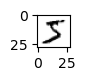

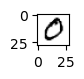

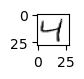

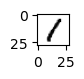

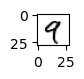

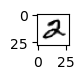

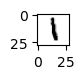

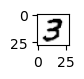

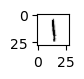

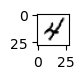

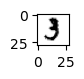

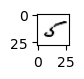

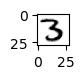

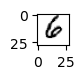

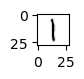

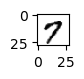

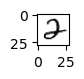

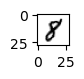

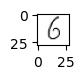

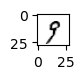

In [7]:
plt.figure(figsize=(5,5)) 
for k in range(20): 
    plt.subplot(10,2,k+1)
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('on') 
    plt.show()

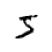

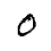

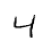

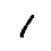

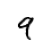

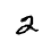

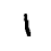

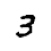

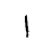

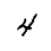

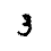

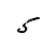

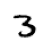

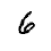

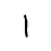

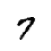

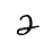

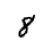

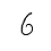

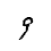

In [8]:
plt.figure(figsize=(5,5))
for k in range(20): 
    plt.subplot(10,2,k+1) 
    plt.imshow(x_train[k],cmap='Greys') 
    plt.axis('off')
    plt.show()

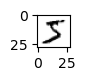

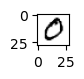

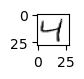

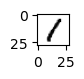

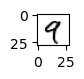

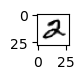

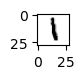

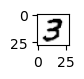

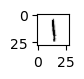

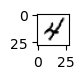

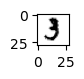

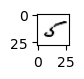

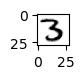

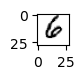

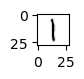

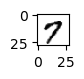

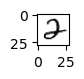

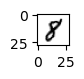

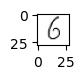

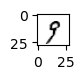

In [9]:
plt.figure(figsize=(5,5)) 
for k in range(20): 
    plt.subplot(10,2,k+1)
    plt.imshow(x_train[k],cmap='Greys')
    plt.axis('on')
    plt.show()

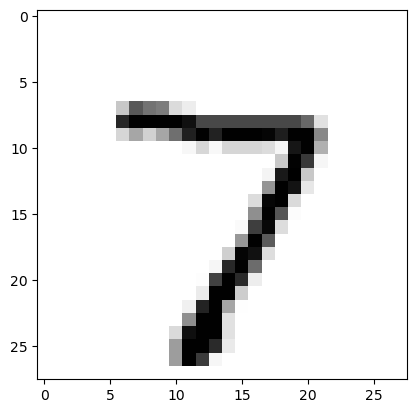

In [10]:
plt.imshow(x_valid[0],cmap='Greys')

In [11]:
y_valid.shape

(10000,)

In [12]:
x_valid[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [13]:
y_valid[0]

np.uint8(7)

In [14]:
x_train = x_train.reshape(60000,784).astype('float32') 
x_valid = x_valid.reshape(10000,784).astype('float32')
x_train/=255 
x_valid/=255

In [16]:
from keras import utils as np_utils
n_classes = 10 
y_train = np_utils.to_categorical(y_train,n_classes) 
y_valid= np_utils.to_categorical(y_valid,n_classes)

In [17]:
y_valid[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [18]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [19]:
x_valid[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [20]:
x_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [21]:
x_valid[3]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [22]:
y_valid[3]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [24]:
model = Sequential()

In [25]:
model.add(Dense(64, activation='sigmoid', input_shape=(784,))) 

In [26]:
model.add(Dense(10, activation='softmax')) 

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
(64*784) 

50176

In [29]:
(64*784)+64

50240

In [30]:
(10*64)

640

In [31]:
(10*64)+10

650

In [32]:
((10*64)+10) +((64*784)+64)

50890

In [34]:
model.compile(loss='mean_squared_error',optimizer=SGD(learning_rate=0.03),metrics=['accuracy'])

In [35]:
history= model.fit(x_train,y_train,batch_size=128,epochs=75,verbose=1)

Epoch 1/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1365 - loss: 0.0905
Epoch 2/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.1859 - loss: 0.0891
Epoch 3/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - accuracy: 0.2294 - loss: 0.0881
Epoch 4/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.2610 - loss: 0.0871
Epoch 5/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - accuracy: 0.2875 - loss: 0.0862
Epoch 6/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3076 - loss: 0.0851 
Epoch 7/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3376 - loss: 0.0841  
Epoch 8/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.3902 - loss: 0.0829
Epoch 9/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.4275 - loss: 0.0817
Epoch 10/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4551 - loss: 0.0805  
Epoch 11/75
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4740 - loss: 0.0792 
Epoch 12/75
469/469 ━━━━━━━━━━━━━━

Text(0, 0.5, 'epoch')

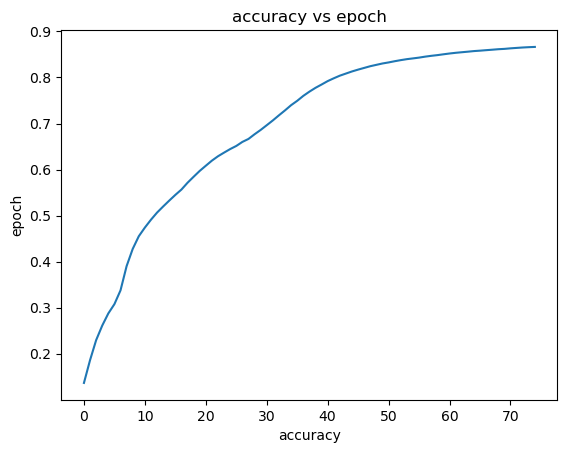

In [36]:
plt.plot(history.history['accuracy']) 
plt.title('accuracy vs epoch')
plt.xlabel('accuracy') 
plt.ylabel('epoch')

Text(0, 0.5, 'epoch')

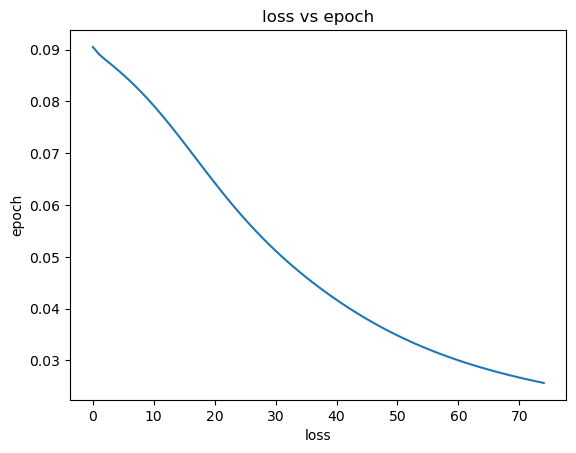

In [37]:
plt.plot(history.history['loss'])
plt.title('loss vs epoch') 
plt.xlabel('loss') 
plt.ylabel('epoch')